<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/colab/Medidas%20contaminaci%C3%B3n%20ayuntamientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de la Calidad del Aire Urbano: Murcia y Cartagena

En esta sección se evalúa la **contaminación de origen antropogénico**.

Como indicador principal se utiliza el **Dióxido de Nitrógeno (NO₂)**, dado que cuenta con una vida atmosférica más corta y está directamente correlacionado con los procesos de combustión interna del tráfico rodado en entornos urbanos.

In [13]:
#@title 🔧 1. Carga de Datos y Limpieza { display-mode: "form" }
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. Configuración de entorno
if not os.path.isdir('/content/drive'):
    drive.mount('/content/drive')

PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Analisis_Contaminacion_Urbana")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# 2. Carga y Preparación
df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df_urbano = df[df['Estacion'].isin(['Murcia Capital', 'Cartagena'])].copy()
df_urbano['fecha'] = df_urbano['time'].dt.date
df_urbano['anio'] = df_urbano['time'].dt.year

## 1. Tendencia Temporal: Evolución de NO₂

Para esta visualización, hemos aplicado una **media móvil de 30 días (ventana de 240 registros)**. Este procesamiento permite eliminar el "ruido" de la variabilidad diaria (ciclos día/noche y fines de semana) y observar la tendencia estructural a largo plazo.

*   **Interpretación:** La línea roja discontinua representa el inicio de las medidas de gestión de tráfico en 2023. Observaremos si existe un cambio de pendiente significativo en los niveles de emisión tras la implementación de políticas urbanas.

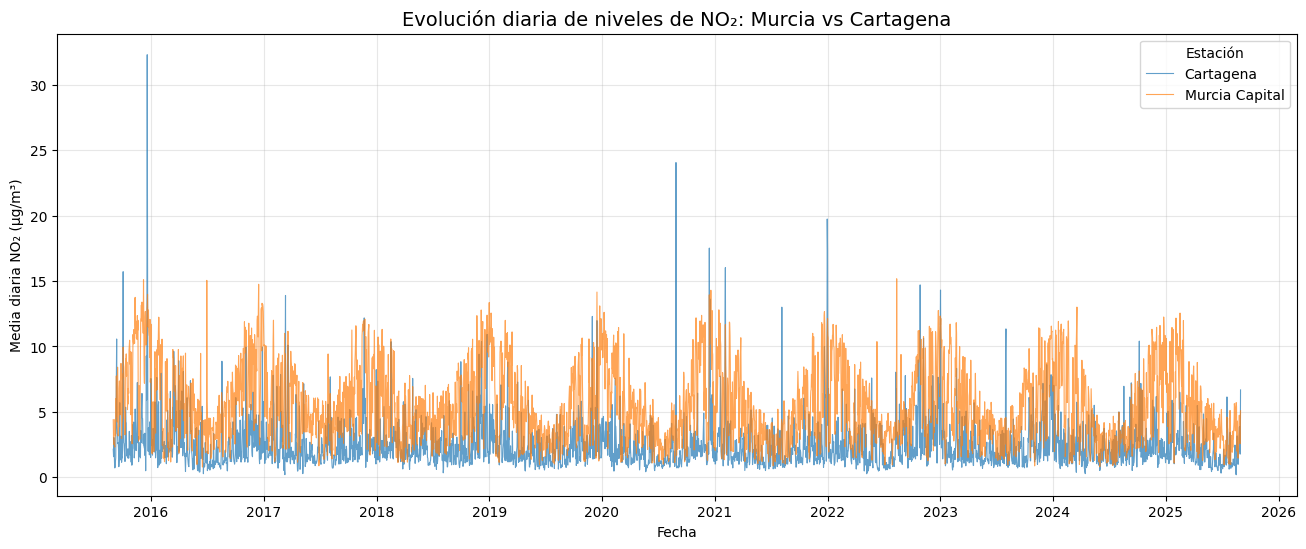

In [14]:
#@title 📈 2. Gráfico: Tendencia Evolución Diaria { display-mode: "form" }
df_diario = df_urbano.groupby(['fecha', 'Estacion'])['NO2'].mean().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=df_diario, x='fecha', y='NO2', hue='Estacion', linewidth=0.8, alpha=0.7)
plt.title("Evolución diaria de niveles de NO₂: Murcia vs Cartagena", fontsize=14)
plt.ylabel("Media diaria NO₂ (µg/m³)")
plt.xlabel("Fecha")
plt.legend(loc='upper right', title="Estación")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RUTA_OUTPUT, "Evolucion_Diaria_NO2.png"), dpi=300)
plt.show()

## 2. Estudio de Caso: El impacto de la pandemia (2020)

El año 2020 representa una anomalía estadística necesaria para validar la sensibilidad de nuestro modelo. Comparamos el periodo de confinamiento estricto (marzo-mayo) con el comportamento histórico de los niveles de contaminación.

*   **Objetivo:** Discernir entre la reducción de emisiones forzada por el cese de actividad social frente al comportamiento estacional "restante" del año. Este contraste valida que las herramientas estadísticas utilizadas son capaces de detectar cambios bruscos en la movilidad urbana.

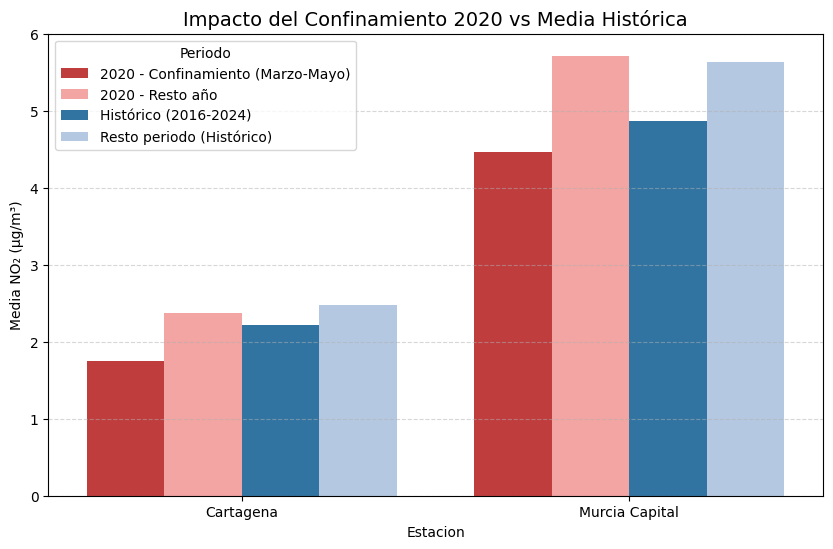

In [15]:
#@title 📉 3. Gráfico: Impacto del Confinamiento 2020 vs Histórico { display-mode: "form" }
def asignar_categoria(row):
    if row['anio'] == 2020:
        return '2020 - Confinamiento (Marzo-Mayo)' if 3 <= row['time'].month <= 5 else '2020 - Resto año'
    else:
        return 'Histórico (2016-2024)' if 3 <= row['time'].month <= 5 else 'Resto periodo (Histórico)'

df_urbano['Categoria'] = df_urbano.apply(asignar_categoria, axis=1)
# Excluimos el año 2020 del cálculo histórico para que la comparación sea justa
resumen_pandemia = df_urbano[df_urbano['anio'] != 2020].copy()
resumen_pandemia = pd.concat([resumen_pandemia, df_urbano[df_urbano['anio'] == 2020]])
resumen_pandemia = resumen_pandemia.groupby(['Estacion', 'Categoria'])['NO2'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_pandemia, x='Estacion', y='NO2', hue='Categoria',
            palette=['#d62728', '#ff9896', '#1f77b4', '#aec7e8'])
plt.title("Impacto del Confinamiento 2020 vs Media Histórica", fontsize=14)
plt.ylabel("Media NO₂ (µg/m³)")
plt.legend(loc='upper left', title="Periodo")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig(os.path.join(RUTA_OUTPUT, "Impacto_Pandemia_vs_Historico.png"), dpi=300)
plt.show()

## 3. Comparativa Interanual: Evolución Media (2016-2024)

El presente gráfico sintetiza la media aritmética diaria de las concentraciones de NO₂ agrupadas por año. Esta métrica es la referencia estándar utilizada en las normativas europeas (Directiva 2008/50/CE) para evaluar la exposición ciudadana.

*   **Nota metodológica:** Las medias presentadas en los gráficos han sido calculadas descartando valores nulos para garantizar la robustez estadística de la serie temporal.

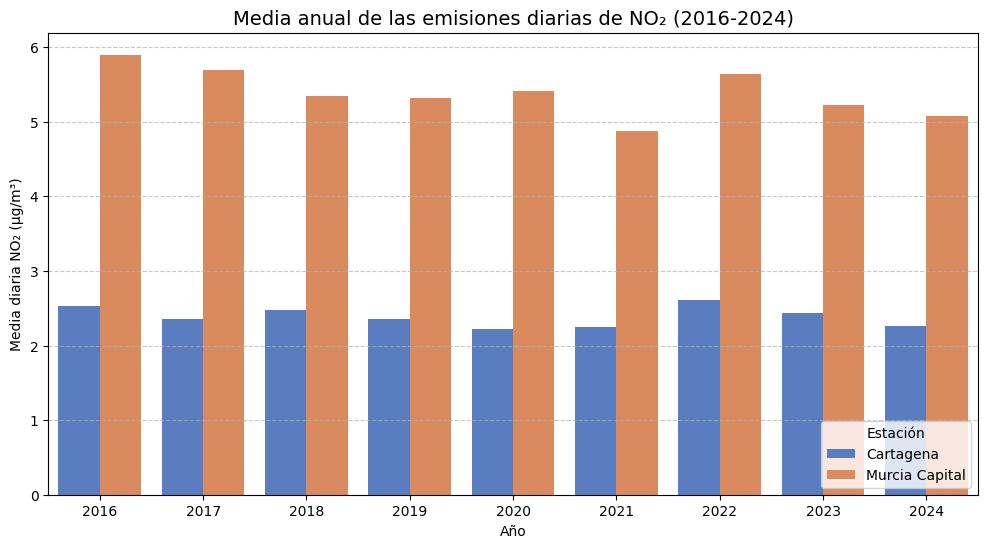

✅ Análisis finalizado. Gráficas y tablas guardadas en: /content/drive/MyDrive/TFM_Profesorado/Analisis_Contaminacion_Urbana


In [16]:
#@title 📊 4. Gráfico: Comparativa Anual de Emisiones { display-mode: "form" }
media_anual = df_urbano.groupby(['anio', 'Estacion'])['NO2'].mean().reset_index()
# Aseguramos el rango estricto 2016-2024
media_anual = media_anual[(media_anual['anio'] >= 2016) & (media_anual['anio'] <= 2024)]

plt.figure(figsize=(12, 6))
sns.barplot(data=media_anual, x='anio', y='NO2', hue='Estacion', palette='muted')
plt.title("Media anual de las emisiones diarias de NO₂ (2016-2024)", fontsize=14)
plt.ylabel("Media diaria NO₂ (µg/m³)")
plt.xlabel("Año")
plt.legend(loc='lower right', title="Estación")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(RUTA_OUTPUT, "Media_Anual_NO2_Barras.png"), dpi=300)
plt.show()

# Exportar tabla resumen final
media_anual.to_csv(os.path.join(RUTA_OUTPUT, "Tabla_NO2_Media_Anual.csv"), index=False)
print(f"✅ Análisis finalizado. Gráficas y tablas guardadas en: {RUTA_OUTPUT}")
